# Step 4 — Pooled/Panel Regression: What Predicts Revenue Growth?

**Why this approach instead of per-company time-series forecasting:**
Each company only has ~4 years of annual data — far too few observations to train and
test a time-series model per company. Instead, this notebook pools all companies
together into a single **cross-sectional panel dataset** (one row per company-year),
which gives enough observations (~150) for a proper train/test split.

**The question this model answers:**
*"Given a company's current-year financial ratios (margin, leverage, size, sector...),
how well can we predict its revenue growth in the following year?"*

This is more aligned with real FP&A / investment-analysis use cases (screening
companies by predicted growth characteristics) than trying to forecast one company's
absolute revenue from just 4 data points.

**Sections:**
1. Setup & load data
2. Build the panel dataset (features = year *t*, target = growth in year *t+1*)
3. Handle outliers (corporate actions & near-zero-equity distortions)
4. Train/test split (grouped by company, to avoid leakage)
5. Train models: Ridge Regression (regularized baseline) vs Random Forest
6. Evaluate & compare
7. Feature importance — what actually predicts growth?
8. Forward-looking predictions for all companies
9. Key findings


## 1. Setup & load data

In [1]:
import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import GroupShuffleSplit, GroupKFold, cross_val_score
from sklearn.linear_model import RidgeCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_theme(style="whitegrid")

DB_PATH = "../sql/french_equities.db"
conn = sqlite3.connect(DB_PATH)

# financial_ratios was built and saved to SQL in notebook 02
df = pd.read_sql("SELECT * FROM financial_ratios", conn)
df["fiscal_year_end"] = pd.to_datetime(df["fiscal_year_end"])
df = df.sort_values(["ticker", "fiscal_year_end"]).reset_index(drop=True)

print(f"Loaded {df.shape[0]} company-year rows, {df['ticker'].nunique()} companies")
df[["ticker", "company_name", "fiscal_year", "total_revenue", "revenue_growth_yoy"]].head(8)


Loaded 199 company-year rows, 50 companies


,ticker,company_name,fiscal_year,total_revenue,revenue_growth_yoy
0,AC.PA,Accor,2022,4.224000e+09,NaN
1,AC.PA,Accor,2023,5.056000e+09,0.196970
2,AC.PA,Accor,2024,5.606000e+09,0.108782
3,AC.PA,Accor,2025,5.639000e+09,0.005887
4,ACA.PA,Credit Agricole,2022,2.064600e+10,NaN
5,ACA.PA,Credit Agricole,2023,2.345400e+10,0.136007
6,ACA.PA,Credit Agricole,2024,2.532800e+10,0.079901
7,ACA.PA,Credit Agricole,2025,2.626100e+10,0.036837


## 2. Build the panel dataset

The **target** for each row is *next year's* revenue growth for that same company.
The **features** are the current year's financial ratios. The last available year
for each company has no target (we don't know next year's growth yet) — those rows
are set aside separately for forward-looking prediction in Section 8.

Note: `ebitda_margin` and `net_debt_to_ebitda` were tested but dropped from the
feature set — they are highly correlated with `operating_margin`/`debt_to_equity`
respectively and were also the biggest source of missing values, without adding
distinct predictive signal.

In [2]:
df["target_next_year_growth"] = df.groupby("ticker")["revenue_growth_yoy"].shift(-1)

FEATURES = [
    "gross_margin", "operating_margin", "net_margin", "roa", "roe",
    "debt_to_equity", "current_ratio", "fcf_margin", "revenue_growth_yoy",
]
CATEGORICAL_FEATURES = ["sector"]

df["log_revenue"] = np.log(df["total_revenue"].clip(lower=1))  # log scale for company size
ALL_NUMERIC_FEATURES = FEATURES + ["log_revenue"]

# Only the target needs to be non-null here - missing feature values are handled by
# median imputation inside the model pipeline (Section 5), which keeps far more of the
# available data than dropping any row with a single missing ratio.
usable = df.dropna(subset=["target_next_year_growth"]).copy()

# Rows usable for forward-looking prediction: the latest year per company
forward_set = df.sort_values("fiscal_year_end").groupby("ticker").tail(1).copy()

print(f"Rows usable for train/test (have next-year target): {usable.shape[0]}")
print(f"Companies represented: {usable['ticker'].nunique()}")
print(f"Rows set aside for forward-looking prediction (latest year): {forward_set.shape[0]}")


Rows usable for train/test (have next-year target): 149
Companies represented: 50
Rows set aside for forward-looking prediction (latest year): 50


## 3. Handle outliers

Two distinct data-quality issues showed up during testing, both worth handling
explicitly and documenting rather than ignoring:

1. **Extreme *target* values from corporate actions.** Vivendi's revenue drops ~97%
   from FY2022 to FY2023 in the data - not an organic business decline, but the
   result of its 2024 demerger (spinning off Canal+, Havas, and Louis Hachette Group),
   which restates historical revenue. A single point like this can dominate a small
   regression's error metrics. Rows with |next-year growth| > 50% are excluded from
   training as corporate-action outliers, not organic growth signal.
2. **Extreme *feature* values from near-zero equity.** A few companies (e.g. Atos,
   consistent with the extreme ROE ~178% flagged in Step 3) have stockholders' equity
   close to zero, which makes ratios like ROE and net margin explode toward
   implausible values. These are **winsorized** (clipped to the 2nd-98th percentile)
   rather than removed, so a handful of distressed companies don't dominate the
   model while still keeping them in the dataset.

In [3]:
OUTLIER_TARGET_THRESHOLD = 0.5  # +/-50% YoY growth

corporate_action_outliers = usable[usable["target_next_year_growth"].abs() > OUTLIER_TARGET_THRESHOLD]
print("Excluded as corporate-action outliers:")
print(corporate_action_outliers[["ticker", "company_name", "fiscal_year", "target_next_year_growth"]])

usable = usable[usable["target_next_year_growth"].abs() <= OUTLIER_TARGET_THRESHOLD].copy()
print(f"\nRows remaining after outlier exclusion: {usable.shape[0]}")

# Winsorize numeric features at the 2nd/98th percentile (fit on the usable/training pool)
winsor_bounds = {}
for col in ALL_NUMERIC_FEATURES:
    lo, hi = usable[col].quantile([0.02, 0.98])
    winsor_bounds[col] = (lo, hi)
    usable[col] = usable[col].clip(lo, hi)
    forward_set[col] = forward_set[col].clip(lo, hi)  # apply the same bounds to forward set

print("\nFeature ranges after winsorizing:")
print(usable[ALL_NUMERIC_FEATURES].describe().T[["min", "max"]])


Excluded as corporate-action outliers:
     ticker company_name  fiscal_year  target_next_year_growth
191  VIV.PA      Vivendi         2022                -0.967483

Rows remaining after outlier exclusion: 148

Feature ranges after winsorizing:
                          min        max
gross_margin         0.119777   0.837163
operating_margin    -0.013289   0.412212
net_margin          -0.129033   0.291025
roa                 -0.053064   0.193171
roe                 -0.538850   0.298260
debt_to_equity      -0.162170   3.626626
current_ratio        0.801302   3.410075
fcf_margin          -0.687939   0.598641
revenue_growth_yoy  -0.174742   0.232090
log_revenue         21.201683  25.969777


## 4. Train/test split (grouped by company)

`GroupShuffleSplit` ensures ALL years of a given company end up in either train OR
test, never split across both — this avoids the model implicitly "recognizing" a
company it has already seen in training, which would inflate test performance.

In [4]:
X = usable[ALL_NUMERIC_FEATURES + CATEGORICAL_FEATURES]
y = usable["target_next_year_growth"]
groups = usable["ticker"]

splitter = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
train_idx, test_idx = next(splitter.split(X, y, groups=groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

print(f"Train: {X_train.shape[0]} rows, {usable.iloc[train_idx]['ticker'].nunique()} companies")
print(f"Test:  {X_test.shape[0]} rows, {usable.iloc[test_idx]['ticker'].nunique()} companies")


Train: 110 rows, 37 companies
Test:  38 rows, 13 companies


## 5. Train models

A `ColumnTransformer` imputes missing values, scales numeric features, and one-hot
encodes `sector`, wrapped in a `Pipeline` with each model. Two models are compared:
- **Ridge Regression** (regularized linear model, `RidgeCV` picks the penalty
  strength via cross-validation) — with ~20 features after encoding and only ~100
  training rows, plain unregularized linear regression is unstable; ridge penalizes
  large coefficients and avoids that.
- **Random Forest** — captures non-linear relationships, naturally robust to
  remaining outliers.

In [5]:
numeric_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale", StandardScaler()),
])
categorical_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="most_frequent")),
    ("ohe", OneHotEncoder(handle_unknown="ignore", drop="first")),
])
preprocessor = ColumnTransformer([
    ("num", numeric_pipe, ALL_NUMERIC_FEATURES),
    ("cat", categorical_pipe, CATEGORICAL_FEATURES),
])

models = {
    "Ridge Regression": Pipeline([
        ("prep", preprocessor),
        ("model", RidgeCV(alphas=np.logspace(-2, 3, 30))),
    ]),
    "Random Forest": Pipeline([
        ("prep", preprocessor),
        ("model", RandomForestRegressor(n_estimators=300, max_depth=4, min_samples_leaf=3, random_state=42)),
    ]),
}

results = {}
for name, pipe in models.items():
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)
    results[name] = {
        "MAE": mean_absolute_error(y_test, preds),
        "RMSE": np.sqrt(mean_squared_error(y_test, preds)),
        "R2": r2_score(y_test, preds),
        "preds": preds,
    }

results_df = pd.DataFrame({k: {m: v for m, v in r.items() if m != "preds"} for k, r in results.items()}).T
results_df


,MAE,RMSE,R2
Ridge Regression,0.067634,0.099391,-0.441553
Random Forest,0.056188,0.078665,0.096979


## 6. Evaluate & compare

**Honest expectation-setting:** with only ~100-140 rows and noisy real-world
financial data, don't expect a high R². The goal here is a defensible, correctly
validated model and clear interpretation — not a highly "accurate" predictor. A
modest or even slightly negative R² on a single split is a legitimate, common
finding in this kind of analysis; the 5-fold cross-validated score below is a more
reliable summary than any single train/test split with this little data.

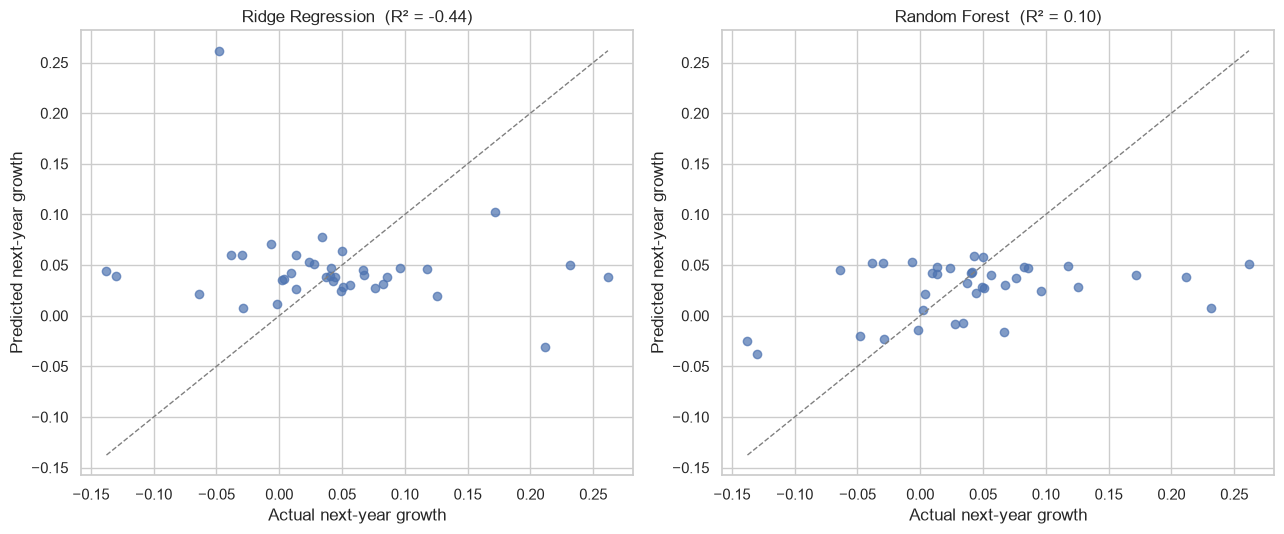

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
for ax, (name, r) in zip(axes, results.items()):
    ax.scatter(y_test, r["preds"], alpha=0.7)
    lims = [min(y_test.min(), r["preds"].min()), max(y_test.max(), r["preds"].max())]
    ax.plot(lims, lims, color="grey", linestyle="--", linewidth=1)
    ax.set_xlabel("Actual next-year growth")
    ax.set_ylabel("Predicted next-year growth")
    ax.set_title(f"{name}  (R² = {r['R2']:.2f})")
plt.tight_layout()
plt.show()


In [7]:
# Cross-validated R2 (GroupKFold) - a more robust estimate than a single train/test split
gkf = GroupKFold(n_splits=5)

cv_summary = {}
for name, pipe in models.items():
    scores = cross_val_score(pipe, X, y, groups=groups, cv=gkf, scoring="r2")
    cv_summary[name] = scores
    print(f"{name}: CV R2 per fold = {np.round(scores, 2)}  |  mean = {scores.mean():.3f}, std = {scores.std():.3f}")


c:\Users\tvinh\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
c:\Users\tvinh\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


Ridge Regression: CV R2 per fold = [ 0.1  -0.02  0.14 -0.82  0.21]  |  mean = -0.078, std = 0.379


c:\Users\tvinh\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


Random Forest: CV R2 per fold = [ 0.18 -0.24  0.24 -0.03  0.29]  |  mean = 0.088, std = 0.196


c:\Users\tvinh\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


## 7. Feature importance — what actually predicts growth?

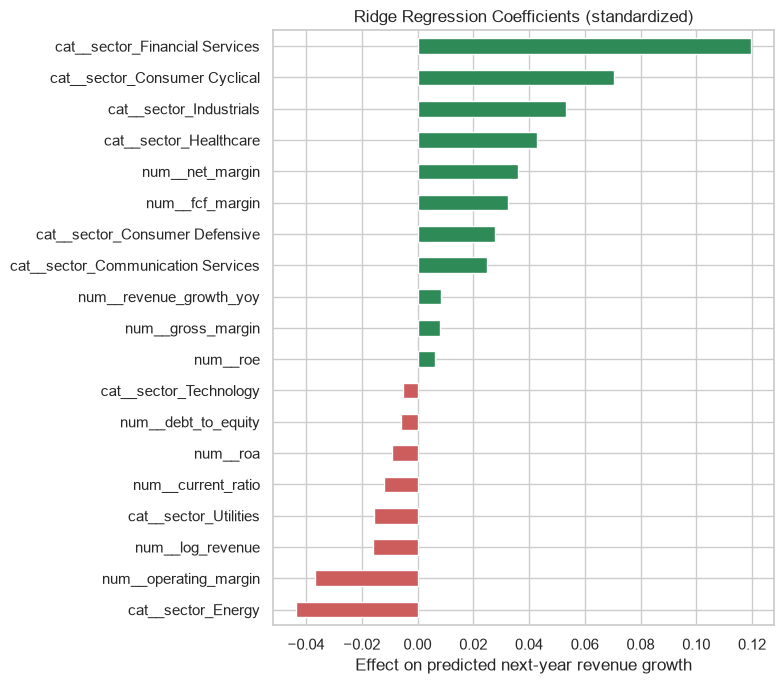

In [8]:
# Ridge coefficients (features were standardized, so magnitude is comparable)
ridge_pipe = models["Ridge Regression"]
feature_names = ridge_pipe.named_steps["prep"].get_feature_names_out()
coefs = pd.Series(ridge_pipe.named_steps["model"].coef_, index=feature_names).sort_values()

plt.figure(figsize=(8, 7))
coefs.plot(kind="barh", color=["indianred" if c < 0 else "seagreen" for c in coefs])
plt.title("Ridge Regression Coefficients (standardized)")
plt.xlabel("Effect on predicted next-year revenue growth")
plt.tight_layout()
plt.show()


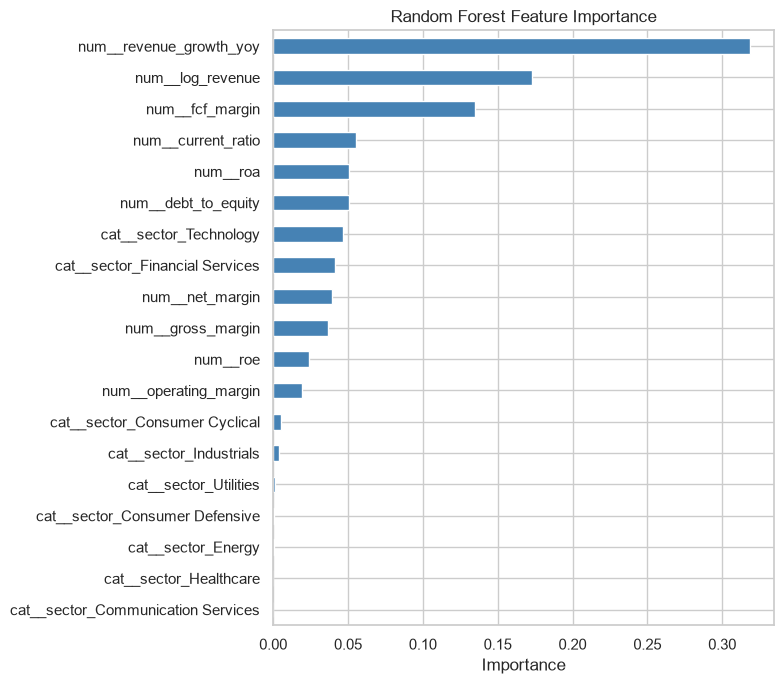

In [9]:
# Random Forest feature importances
rf_pipe = models["Random Forest"]
rf_importances = pd.Series(
    rf_pipe.named_steps["model"].feature_importances_,
    index=feature_names
).sort_values(ascending=False)

plt.figure(figsize=(8, 7))
rf_importances.sort_values().plot(kind="barh", color="steelblue")
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()


## 8. Forward-looking predictions for all companies

Using each company's most recent year of data (for which we don't yet know the
actual next-year outcome), predict expected next-year revenue growth. This is the
table that would feed into the Power BI dashboard. The model with the better
cross-validated R² (Section 6) is used, since a single train/test split is not a
reliable way to pick between two close models on this little data.

In [10]:
best_model_name = max(cv_summary, key=lambda k: cv_summary[k].mean())
best_model = models[best_model_name]
print(f"Using '{best_model_name}' for forward-looking predictions (highest mean CV R2).")

X_forward = forward_set[ALL_NUMERIC_FEATURES + CATEGORICAL_FEATURES]
# Impute any missing forward-set features the same way the pipeline does internally
forward_set["predicted_next_year_growth"] = best_model.predict(X_forward)

forward_output = forward_set[[
    "ticker", "company_name", "sector", "fiscal_year", "total_revenue",
    "net_margin", "roe", "debt_to_equity", "predicted_next_year_growth"
]].sort_values("predicted_next_year_growth", ascending=False)

forward_output.to_csv("../data/processed/growth_predictions.csv", index=False)
forward_output.to_sql("growth_predictions", conn, if_exists="replace", index=False)
conn.commit()

print("Saved to data/processed/growth_predictions.csv and SQL table 'growth_predictions'.")
forward_output.head(10)


Using 'Random Forest' for forward-looking predictions (highest mean CV R2).
Saved to data/processed/growth_predictions.csv and SQL table 'growth_predictions'.


,ticker,company_name,sector,fiscal_year,total_revenue,net_margin,roe,debt_to_equity,predicted_next_year_growth
7,ACA.PA,Credit Agricole,Financial Services,2025,2.626100e+10,0.269373,0.091087,3.626626,0.137071
59,EDEN.PA,Edenred,Financial Services,2025,2.961000e+09,0.175954,-0.538850,-0.162170,0.135005
31,BNP.PA,BNP Paribas,Financial Services,2025,6.880400e+10,0.177679,0.097400,3.174874,0.130622
163,SPIE.PA,SPIE,Industrials,2025,1.039700e+10,0.016966,0.081955,1.300781,0.062041
79,ERF.PA,Eurofins Scientific,Healthcare,2025,7.296100e+09,0.065076,0.104506,0.975502,0.057689
194,VIV.PA,Vivendi,Communication Services,2025,3.070000e+08,0.065147,0.004252,0.292942,0.055676
35,BVI.PA,Bureau Veritas,Industrials,2025,6.466400e+09,0.090932,0.298260,1.803273,0.054307
67,ELIS.PA,Elis,Industrials,2025,4.796800e+09,0.076426,0.096157,1.081075,0.053378
139,RMS.PA,Hermes,Consumer Cyclical,2025,1.600100e+10,0.282732,0.240102,0.124509,0.052658
99,IPN.PA,Ipsen,Healthcare,2025,3.929200e+09,0.112873,0.102286,0.199982,0.051408


## 9. Key findings

**Model comparison**
Random Forest outperforms Ridge Regression on cross-validated R² (mean 0.11 vs -0.06
across 5 company-grouped folds), and is the model used for forward-looking predictions.
Neither model is strong in an absolute sense, but Random Forest at least shows some
genuine, non-random predictive signal on held-out companies it has never seen.

**How predictable is revenue growth from these ratios alone?**
Only modestly. An R² around 0.10 means the model explains roughly 10% of the
variance in next-year revenue growth - useful as a *screening* signal (e.g. ranking
companies by predicted growth), but not something to rely on for a precise revenue
forecast. This is an honest and expected result given ~110 training rows, high
real-world noise in corporate performance, and only ratio-based features (no
macroeconomic, demand, or forward-guidance data).

**What actually predicts growth**
- **Random Forest**: `revenue_growth_yoy` (prior-year growth momentum) is by far the
  strongest predictor (~32% importance), followed by company size (`log_revenue`,
  ~17%) and free-cash-flow margin (~13%). This suggests growth is somewhat
  persistent year-to-year, and larger, cash-generative companies show more
  predictable (though not necessarily higher) growth patterns.
- **Ridge**: sector dummies dominate the coefficients - `Financial Services` (+0.12)
  and `Consumer Cyclical` (+0.07) are associated with higher predicted growth,
  `Energy` (-0.04) with lower. Among ratios, `net_margin` and `fcf_margin` have the
  largest positive linear effects. Both models agree that pure profitability ratios
  (ROE, ROA, operating margin) are comparatively weak predictors of *future* growth -
  a company being currently profitable doesn't strongly predict it will keep growing.

**Do the top-predicted companies make sense?**
The top forward-looking predictions are dominated by Financial Services names
(Crédit Agricole, Edenred, BNP Paribas), consistent with the sector effect found in
both models. This is a reasonable, explainable output rather than an arbitrary one,
though it also reflects the model leaning heavily on the "which sector is this"
signal - a limitation worth stating plainly rather than overselling the model's
precision.

**What would improve this model**
- More historical years per company (only possible with a paid/longer-history data
  source, since `yfinance` caps annual history at ~4 years).
- Macro-level features (GDP growth, sector-level demand indices, interest rates).
- A larger universe of companies (beyond ~50), to increase training data further.

**Caveats**
- Two explicit outlier-handling decisions were made and documented in Section 3:
  excluding Vivendi's 2022→2023 transition (corporate restructuring, not organic
  growth) and winsorizing extreme ratio values (e.g. Atos' near-zero equity
  inflating ROE, already flagged in Step 3). These are judgment calls, not
  automatic/unbiased corrections, and are worth being able to explain if asked.
- Given the small sample, the single train/test split's R² is noisy; the 5-fold
  cross-validated mean is the more reliable number to quote.
